In [10]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Rutas
CLIPS_DIR     = Path('./data/clips')
LANDMARKS_DIR = Path('./data/landmarks')
LANDMARKS_DIR.mkdir(parents=True, exist_ok=True)

# Clases a procesar (carpetas dentro de clips/)
CLASES = ['QUE1', 'QUIEN1', 'NADA', 'DONDE', 'POR_QUE']

print('Librerías cargadas OK')
print(f'Clips en: {CLIPS_DIR.resolve()}')
print(f'Landmarks en: {LANDMARKS_DIR.resolve()}')

Librerías cargadas OK
Clips en: /home/pierov/piero/projects/whqlsp-detector/notebooks/data/clips
Landmarks en: /home/pierov/piero/projects/whqlsp-detector/notebooks/data/landmarks


## mediapipe

In [11]:
import mediapipe as mp
print(mp.__version__)

0.10.9


In [12]:
mp_hands = mp.solutions.hands
mp_draw  = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

print('MediaPipe Hands inicializado OK')
print(f'  max_num_hands: 2')
print(f'  min_detection_confidence: 0.5')

MediaPipe Hands inicializado OK
  max_num_hands: 2
  min_detection_confidence: 0.5


I0000 00:00:1781586885.972677   40084 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781586886.033202   41773 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.309.01), renderer: NVIDIA GeForce GTX 1050/PCIe/SSE2


Manos detectadas: 2
  Mano 1: Right (confianza: 0.96)
  Mano 2: Left (confianza: 0.98)


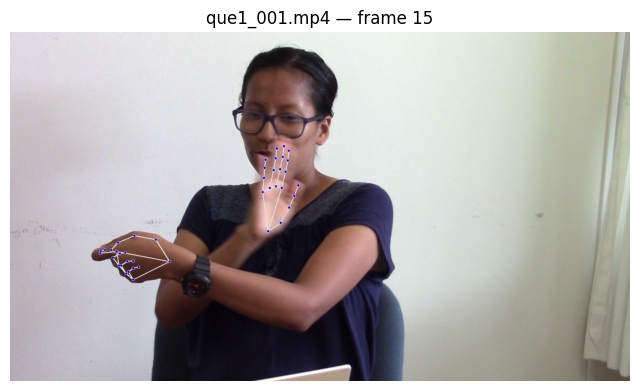

In [13]:
def ver_landmarks_en_frame(clip_path: Path, frame_num: int = 15):
    """
    Extrae un frame del clip, corre MediaPipe y dibuja los landmarks.
    frame_num: qué frame ver (15 = medio segundo aprox a 30fps)
    """
    cap = cv2.VideoCapture(str(clip_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ok, frame = cap.read()
    cap.release()
    
    if not ok:
        print(f'No se pudo leer el frame {frame_num}')
        return
    
    # MediaPipe espera RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resultado = hands.process(frame_rgb)
    
    # Dibujar landmarks si detectó manos
    frame_draw = frame_rgb.copy()
    if resultado.multi_hand_landmarks:
        for hand_landmarks in resultado.multi_hand_landmarks:
            mp_draw.draw_landmarks(
                frame_draw,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )
        print(f'Manos detectadas: {len(resultado.multi_hand_landmarks)}')
        for i, hand in enumerate(resultado.multi_handedness):
            print(f'  Mano {i+1}: {hand.classification[0].label} '
                  f'(confianza: {hand.classification[0].score:.2f})')
    else:
        print('⚠️  No se detectaron manos en este frame')
    
    plt.figure(figsize=(8, 5))
    plt.imshow(frame_draw)
    plt.title(f'{clip_path.name} — frame {frame_num}')
    plt.axis('off')
    plt.show()


# Probar con el primer clip de QUE1
clips_que1 = sorted((CLIPS_DIR / 'QUE1').glob('*.mp4'))
ver_landmarks_en_frame(clips_que1[0])

In [14]:
def extraer_landmarks_clip(clip_path: Path) -> np.ndarray | None:
    """
    Procesa todos los frames de un clip y extrae landmarks de ambas manos.
    
    Output shape: (n_frames, 2, 21, 3)
        n_frames = cantidad de frames del clip
        2        = mano derecha [0] y mano izquierda [1]
        21       = landmarks por mano
        3        = x, y, z normalizados
    
    Si en un frame no detecta una mano, rellena con ceros.
    """
    cap = cv2.VideoCapture(str(clip_path))
    landmarks_clip = []
    
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resultado = hands.process(frame_rgb)
        
        # Array vacío para este frame: 2 manos x 21 puntos x 3 coords
        frame_landmarks = np.zeros((2, 21, 3), dtype=np.float32)
        
        if resultado.multi_hand_landmarks:
            for hand_landmarks, handedness in zip(
                resultado.multi_hand_landmarks,
                resultado.multi_handedness
            ):
                # 0 = Right, 1 = Left (desde perspectiva cámara)
                idx = 0 if handedness.classification[0].label == 'Right' else 1
                for j, lm in enumerate(hand_landmarks.landmark):
                    frame_landmarks[idx, j] = [lm.x, lm.y, lm.z]
        
        landmarks_clip.append(frame_landmarks)
    
    cap.release()
    
    if len(landmarks_clip) == 0:
        return None
    
    return np.array(landmarks_clip)  # shape: (n_frames, 2, 21, 3)


# Probar con el primer clip
clip_prueba = clips_que1[0]
landmarks = extraer_landmarks_clip(clip_prueba)

print(f'Clip: {clip_prueba.name}')
print(f'Shape: {landmarks.shape}')
print(f'  {landmarks.shape[0]} frames')
print(f'  {landmarks.shape[1]} manos (0=Right, 1=Left)')
print(f'  {landmarks.shape[2]} landmarks por mano')
print(f'  {landmarks.shape[3]} coordenadas (x, y, z)')
print(f'\nFrames con mano derecha detectada: '
      f'{np.any(landmarks[:, 0] != 0, axis=(1,2)).sum()}')
print(f'Frames con mano izquierda detectada: '
      f'{np.any(landmarks[:, 1] != 0, axis=(1,2)).sum()}')

Clip: que1_001.mp4
Shape: (264, 2, 21, 3)
  264 frames
  2 manos (0=Right, 1=Left)
  21 landmarks por mano
  3 coordenadas (x, y, z)

Frames con mano derecha detectada: 161
Frames con mano izquierda detectada: 164


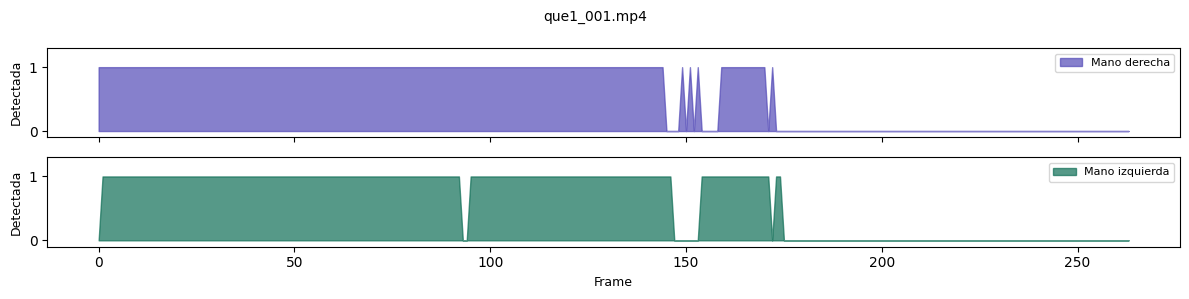

Cobertura mano derecha:   61.0%
Cobertura mano izquierda: 62.1%


In [15]:
def visualizar_deteccion(landmarks: np.ndarray, titulo: str = ''):
    """
    Muestra una línea de tiempo con qué frames tienen detección
    de mano derecha e izquierda.
    """
    derecha  = np.any(landmarks[:, 0] != 0, axis=(1, 2))
    izquierda = np.any(landmarks[:, 1] != 0, axis=(1, 2))
    
    n_frames = len(landmarks)
    frames   = np.arange(n_frames)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 3), sharex=True)
    
    axes[0].fill_between(frames, derecha.astype(int),
                         alpha=0.7, color='#534AB7', label='Mano derecha')
    axes[0].set_ylabel('Detectada', fontsize=9)
    axes[0].set_yticks([0, 1])
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].set_ylim(-0.1, 1.3)
    
    axes[1].fill_between(frames, izquierda.astype(int),
                         alpha=0.7, color='#0F6E56', label='Mano izquierda')
    axes[1].set_ylabel('Detectada', fontsize=9)
    axes[1].set_yticks([0, 1])
    axes[1].set_xlabel('Frame', fontsize=9)
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].set_ylim(-0.1, 1.3)
    
    plt.suptitle(titulo or 'Detección por frame', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Resumen
    pct_d = derecha.mean() * 100
    pct_i = izquierda.mean() * 100
    print(f'Cobertura mano derecha:   {pct_d:.1f}%')
    print(f'Cobertura mano izquierda: {pct_i:.1f}%')
    if pct_d < 50 or pct_i < 50:
        print('⚠️  Cobertura baja — revisar si la seña está siendo capturada')


visualizar_deteccion(landmarks, titulo=clip_prueba.name)

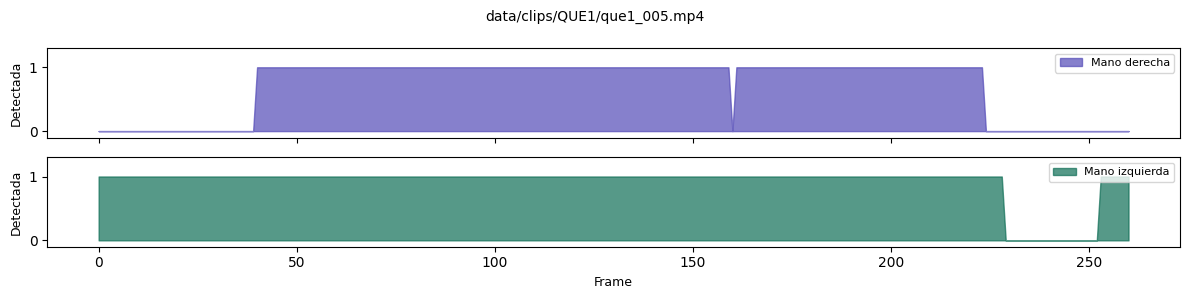

Cobertura mano derecha:   70.1%
Cobertura mano izquierda: 90.8%


In [16]:
clip_prueba = clips_que1[4]
visualizar_deteccion(extraer_landmarks_clip(clip_prueba), titulo=clip_prueba)

In [17]:
def procesar_todos_los_clips(clases: list, clips_dir: Path, output_dir: Path):
    """
    Procesa todos los clips de todas las clases y guarda los landmarks.
    Estructura output:
        landmarks/
        ├── QUE1/
        │   ├── que1_001.npy   # shape: (n_frames, 2, 21, 3)
        │   └── ...
        └── QUIEN1/
            └── ...
    """
    resumen = {}
    
    for clase in clases:
        clips = sorted((clips_dir / clase).glob('*.mp4'))
        output_clase = output_dir / clase
        output_clase.mkdir(parents=True, exist_ok=True)
        resumen[clase] = {'ok': 0, 'error': 0}
        
        print(f'\n{clase} — {len(clips)} clips')
        
        for clip in clips:
            npy_path = output_clase / (clip.stem + '.npy')
            
            if npy_path.exists():
                print(f'  ya existe: {clip.name} — saltando')
                resumen[clase]['ok'] += 1
                continue
            
            landmarks = extraer_landmarks_clip(clip)
            
            if landmarks is None:
                print(f'  ERROR: {clip.name}')
                resumen[clase]['error'] += 1
                continue
            
            np.save(npy_path, landmarks)
            n_frames = landmarks.shape[0]
            pct_d = np.any(landmarks[:, 0] != 0, axis=(1,2)).mean() * 100
            pct_i = np.any(landmarks[:, 1] != 0, axis=(1,2)).mean() * 100
            print(f'  OK: {clip.name} | {n_frames} frames | '
                  f'D:{pct_d:.0f}% I:{pct_i:.0f}%')
            resumen[clase]['ok'] += 1
    
    print('\n--- Resumen ---')
    for clase, r in resumen.items():
        print(f'  {clase}: {r["ok"]} OK, {r["error"]} errores')
    
    return resumen


resumen = procesar_todos_los_clips(CLASES, CLIPS_DIR, LANDMARKS_DIR)


QUE1 — 6 clips
  OK: que1_001.mp4 | 264 frames | D:61% I:62%
  OK: que1_002.mp4 | 257 frames | D:98% I:74%
  OK: que1_003.mp4 | 267 frames | D:33% I:71%
  OK: que1_004.mp4 | 266 frames | D:60% I:99%
  OK: que1_005.mp4 | 261 frames | D:70% I:91%
  OK: que1_006.mp4 | 251 frames | D:84% I:51%

QUIEN1 — 7 clips
  OK: quien1_001.mp4 | 267 frames | D:54% I:61%
  OK: quien1_002.mp4 | 265 frames | D:74% I:64%
  OK: quien1_003.mp4 | 267 frames | D:38% I:100%
  OK: quien1_004.mp4 | 265 frames | D:57% I:98%
  OK: quien1_005.mp4 | 263 frames | D:20% I:90%
  OK: quien1_006.mp4 | 266 frames | D:55% I:53%
  OK: quien1_007.mp4 | 18 frames | D:100% I:100%

NADA — 48 clips
  OK: A-TREVES_1323.mp4 | 29 frames | D:100% I:83%
  OK: ABRIR_2924.mp4 | 13 frames | D:92% I:69%
  OK: ADIVINA_2168.mp4 | 24 frames | D:96% I:96%
  OK: AFUERA-O-SALIR_2913.mp4 | 16 frames | D:88% I:88%
  OK: ALLÁ_562.mp4 | 12 frames | D:8% I:83%
  OK: ALTO_1350.mp4 | 21 frames | D:100% I:19%
  OK: AMIGAS_568.mp4 | 13 frames | D:62% 

In [18]:
def visualizar_clip_con_landmarks(clip_path: Path, output_path: Path = None, 
                                   max_frames: int = None):
    """
    Genera un video con los landmarks de MediaPipe dibujados encima.
    Si output_path es None, solo muestra frames en el notebook.
    """
    cap = cv2.VideoCapture(str(clip_path))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    ancho  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    writer = None
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(str(output_path), fourcc, fps, (ancho, alto))
    
    frames_viz = []
    frame_num = 0
    
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if max_frames and frame_num >= max_frames:
            break
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resultado = hands.process(frame_rgb)
        frame_draw = frame_rgb.copy()
        
        if resultado.multi_hand_landmarks:
            for hand_lm, handedness in zip(resultado.multi_hand_landmarks,
                                           resultado.multi_handedness):
                # Color según mano: púrpura=derecha, verde=izquierda
                label = handedness.classification[0].label
                color = (83, 74, 183) if label == 'Right' else (15, 110, 86)
                
                mp_draw.draw_landmarks(
                    frame_draw, hand_lm, mp_hands.HAND_CONNECTIONS,
                    mp_draw.DrawingSpec(color=color, thickness=2, circle_radius=3),
                    mp_draw.DrawingSpec(color=color, thickness=2)
                )
                
                # Etiqueta de la mano
                x = int(hand_lm.landmark[0].x * ancho)
                y = int(hand_lm.landmark[0].y * alto)
                cv2.putText(frame_draw, label, (x, y - 10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        
        # Número de frame
        cv2.putText(frame_draw, f'Frame {frame_num}', (10, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
        
        if writer:
            writer.write(cv2.cvtColor(frame_draw, cv2.COLOR_RGB2BGR))
        
        frames_viz.append(frame_draw)
        frame_num += 1
    
    cap.release()
    if writer:
        writer.release()
        print(f'Video guardado: {output_path}')
    
    return frames_viz


VIZ_DIR = Path('../data/visualizaciones')
VIZ_DIR.mkdir(exist_ok=True)

for clase in CLASES:
    clips = sorted((CLIPS_DIR / clase).glob('*.mp4'))
    print(f'\n{clase} — {len(clips)} clips')
    
    for clip in clips:
        out = VIZ_DIR / f'{clip.stem}_landmarks.mp4'
        print(f'  Procesando {clip.name}...')
        visualizar_clip_con_landmarks(clip, output_path=out)

print('\nListo — videos en data/visualizaciones/')


QUE1 — 6 clips
  Procesando que1_001.mp4...
Video guardado: ../data/visualizaciones/que1_001_landmarks.mp4
  Procesando que1_002.mp4...
Video guardado: ../data/visualizaciones/que1_002_landmarks.mp4
  Procesando que1_003.mp4...
Video guardado: ../data/visualizaciones/que1_003_landmarks.mp4
  Procesando que1_004.mp4...
Video guardado: ../data/visualizaciones/que1_004_landmarks.mp4
  Procesando que1_005.mp4...
Video guardado: ../data/visualizaciones/que1_005_landmarks.mp4
  Procesando que1_006.mp4...
Video guardado: ../data/visualizaciones/que1_006_landmarks.mp4

QUIEN1 — 7 clips
  Procesando quien1_001.mp4...
Video guardado: ../data/visualizaciones/quien1_001_landmarks.mp4
  Procesando quien1_002.mp4...
Video guardado: ../data/visualizaciones/quien1_002_landmarks.mp4
  Procesando quien1_003.mp4...
Video guardado: ../data/visualizaciones/quien1_003_landmarks.mp4
  Procesando quien1_004.mp4...
Video guardado: ../data/visualizaciones/quien1_004_landmarks.mp4
  Procesando quien1_005.mp4...

KeyboardInterrupt: 